# Import Libraries


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from datasets import Dataset

2025-06-08 13:44:17.214331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749390257.707775      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749390257.832378      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Load the dataset


In [2]:
# Load Data
file_path = '/kaggle/input/personal-care/amazon_reviews_us_Personal_Care_Appliances_v1_00.tsv'
df = pd.read_csv(file_path, on_bad_lines='skip', sep='\t')

# Display the shape of the dataset


In [3]:
print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset contains 85924 rows and 15 columns.



# Display the first few rows


In [4]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32114233,R1QX6706ZWJ1P5,B00OYRW4UE,223980852,Elite Sportz Exercise Sliders are Double Sided...,Personal_Care_Appliances,5,0,0,N,Y,Good quality. Shipped,Exactly as described. Good quality. Shipped fast,2015-08-31
1,US,18125776,R3QWMLJHIW6P37,B0000537JQ,819771537,Ezy Dose Weekly,Personal_Care_Appliances,5,0,0,N,Y,Five Stars,It is great,2015-08-31
2,US,19917519,R14Z1VR1N0Z9G6,B00HXXO332,849307176,"Pulse Oximeter, Blood Oxygen Monitor",Personal_Care_Appliances,5,1,1,N,Y,It's really nice it works great,It's really nice it works great. You have the ...,2015-08-31
3,US,18277171,R25ZRJL0GH0U0,B00EOB0JA2,700864740,SE Tools Tool Kit Watch Watch Repair Kit (20 P...,Personal_Care_Appliances,2,0,0,N,Y,Two Stars,The kit works fine... simple cheap plastic tho,2015-08-31
4,US,2593270,R3837KYH7AZNIY,B00OC2O1UC,794298839,"doTERRA HD Clear Facial Kit - Facial Lotion, F...",Personal_Care_Appliances,4,0,1,N,Y,Four Stars,It works better than anything else ive tried,2015-08-31


# Display column names


In [5]:
print("\nColumn names:")
df.columns.tolist()


Column names:


['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date']

# Display data types and non-null counts


In [6]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85924 entries, 0 to 85923
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   marketplace        85924 non-null  object
 1   customer_id        85924 non-null  int64 
 2   review_id          85924 non-null  object
 3   product_id         85924 non-null  object
 4   product_parent     85924 non-null  int64 
 5   product_title      85920 non-null  object
 6   product_category   85924 non-null  object
 7   star_rating        85924 non-null  int64 
 8   helpful_votes      85924 non-null  int64 
 9   total_votes        85924 non-null  int64 
 10  vine               85924 non-null  object
 11  verified_purchase  85924 non-null  object
 12  review_headline    85923 non-null  object
 13  review_body        85924 non-null  object
 14  review_date        85924 non-null  object
dtypes: int64(5), object(10)
memory usage: 9.8+ MB


# Display summary statistics for numerical columns


In [7]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,8.592400e+04,8.592400e+04,85924.000000,85924.000000,85924.000000
mean,2.943395e+07,5.138159e+08,3.977236,3.351520,4.061357
std,1.525241e+07,2.919951e+08,1.433323,19.489455,20.832674
min,1.047000e+04,3.573000e+03,1.000000,0.000000,0.000000
25%,1.547730e+07,2.628535e+08,3.000000,0.000000,0.000000
50%,2.903199e+07,4.981086e+08,5.000000,0.000000,1.000000
75%,4.372740e+07,7.899794e+08,5.000000,2.000000,3.000000
max,5.309657e+07,9.999599e+08,5.000000,2785.000000,2876.000000


# Check for missing values


In [8]:
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        4
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      1
review_body          0
review_date          0
dtype: int64

# Check rating distribution


 Rating Distribution:


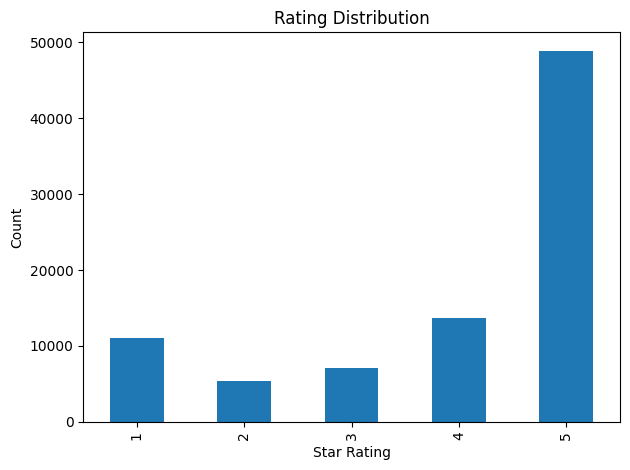

<Figure size 640x480 with 0 Axes>

In [9]:
if 'star_rating' in df.columns:
    print("\n Rating Distribution:")
    df['star_rating'].value_counts().sort_index()

    df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
    plt.xlabel('Star Rating')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()  
    plt.clf()

# Calculate and plot string length (characters)

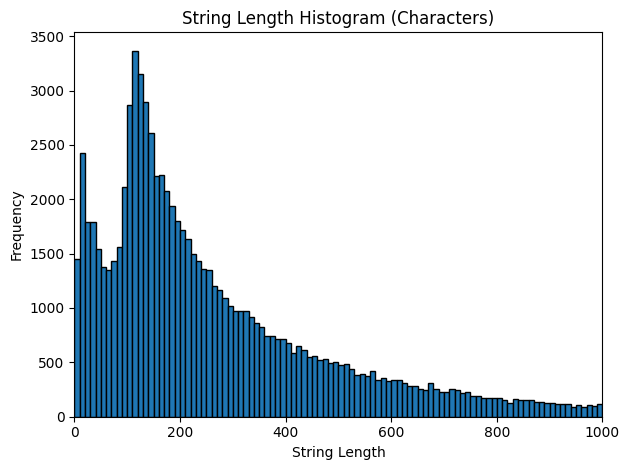

<Figure size 640x480 with 0 Axes>

In [10]:
df['String_Length'] = df['review_body'].astype(str).apply(len)

plt.hist(df['String_Length'], 
         bins=range(0, 1001, 10),  # bin every 10 chars up to 1000
         edgecolor='black')
plt.title('String Length Histogram (Characters)')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()
plt.clf()

# Calculate and plot word count

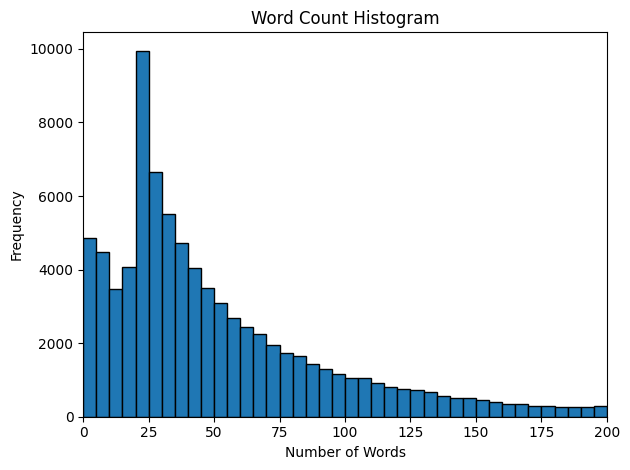

<Figure size 640x480 with 0 Axes>

In [11]:
df['Word_Count'] = df['review_body'].astype(str).apply(lambda x: len(x.split()))

plt.hist(df['Word_Count'], 
         bins=range(0, 201, 5),  # bin every 5 words up to 200
         edgecolor='black')
plt.title('Word Count Histogram')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()
plt.clf()

# 1. Data Preprocessing

# Drop rows with missing values


In [12]:
# Drop unnecessary columns
df = df[['star_rating', 'product_title', 'review_headline', 'review_body']]

# Drop rows with missing values
df.dropna(inplace=True)

# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)


In [13]:
# Convert star ratings to sentiment classes (0: Negative, 1: Neutral, 2: Positive)
df['sentiment'] = df['star_rating'].apply(lambda x: 0 if x <= 2 else (1 if x == 3 else 2))

# Combine 3 columns

In [14]:
# Combine product title, review headline, and review body
df['combined_text'] = df['product_title'] + " " + df['review_headline'] + " " + df['review_body']

# Print class distribution


In [15]:
# Label mapping
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Count occurrences in the full dataset
class_counts = np.bincount(df['sentiment'])
total_samples = len(df)

print("Class Distribution (Full Dataset):")
for label, count in enumerate(class_counts):
    percentage = count / total_samples * 100
    print(f"{label_names[label]}: {count} samples ({percentage:.2f}%)")

Class Distribution (Full Dataset):
Negative: 16372 samples (19.06%)
Neutral: 7043 samples (8.20%)
Positive: 62504 samples (72.75%)


# View cleaned data

In [16]:
print("Sample of Cleaned Reviews with Labels:")
df[['star_rating', 'sentiment', 'combined_text']].sample(10, random_state=42)

Sample of Cleaned Reviews with Labels:


,star_rating,sentiment,combined_text
226,5,2,Viva Naturals #1 Best Selling Certified Organi...
71481,3,1,Clean + Easy Deluxe Home Electrolysis If you h...
72642,5,2,The Acuvibe Wireless Massager Amazing! I first...
11687,1,0,Personal Pedi Water Proof Electronic Hand and ...
71552,5,2,Denman Denman Styling Brush Heavy Weight 9 Row...
37974,5,2,Vktech Replacement Electric Toothbrush Heads P...
58155,4,2,"Lock Laces, Black Good For Those With Little T..."
39741,5,2,Oral-B Power Tip Replacement Electric Toothbru...
28511,2,0,Mega Motion Infinate Position Power Easy Comfo...
48480,5,2,"IQAir Pre-Filter Replacement for HealthPro, He..."


# 2. Split data: 80% train, 10% val, 10% test


In [17]:
# 8:1:1 Data Split (80% train, 10% validation, 10% test)
# First split: 80% train, 20% temp (which will be split into 10% val, 10% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    df["combined_text"], 
    df["sentiment"],
    test_size=0.2, 
    stratify=df["sentiment"], 
    random_state=42
)
# Second split: Split the 20% temp into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp,
    test_size=0.5,  # 0.5 of 20% = 10% of total
    stratify=y_temp, 
    random_state=42
)
print(f"Dataset splits - Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%), "
      f"Val: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%), "
      f"Test: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")


Dataset splits - Train: 68735 (80.0%), Val: 8592 (10.0%), Test: 8592 (10.0%)


# 3. Tokenization and vocabulary


In [18]:
# Tokenization with paper-standard settings
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
def tokenize_function(examples):
    return tokenizer(
        examples["text"], 
        padding="max_length", 
        truncation=True, 
        max_length=128  # Standard BERT max length from paper
    )

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [19]:
# Create Datasets
train_dataset = Dataset.from_dict({"text": list(X_train), "label": list(y_train)})
val_dataset = Dataset.from_dict({"text": list(X_val), "label": list(y_val)})
test_dataset = Dataset.from_dict({"text": list(X_test), "label": list(y_test)})

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/68735 [00:00<?, ? examples/s]

Map:   0%|          | 0/8592 [00:00<?, ? examples/s]

Map:   0%|          | 0/8592 [00:00<?, ? examples/s]

# 4. Model & Custom Trainer


In [20]:
# Class Weights
weights_np = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights_np[1] *= 1.2  # Slight boost to neutral class
weights = torch.tensor(weights_np, dtype=torch.float)

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, alpha=0.75):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.alpha = alpha

    def forward(self, logits, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

# Custom Trainer with Focal Loss and Accuracy Tracking
class FocalLossTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
        # Initialize tracking lists
        self.epoch_train_losses = []
        self.epoch_train_accuracies = []
        self.epoch_val_losses = []
        self.epoch_val_accuracies = []
        
        # Temporary storage for current epoch
        self.current_epoch_losses = []
        self.current_epoch_accuracies = []
        
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits

        device = next(model.parameters()).device
        loss_fn = FocalLoss(gamma=2.0, weight=weights.to(device))
        loss = loss_fn(logits, labels)

        if model.training:  # Ensure tracking is during training only
            with torch.no_grad():
                preds = torch.argmax(logits, dim=-1)
                acc = (preds == labels).float().mean().item()
                self.current_epoch_losses.append(loss.item())
                self.current_epoch_accuracies.append(acc)

        return (loss, outputs) if return_outputs else loss

    def on_epoch_end(self):
        if self.current_epoch_losses:
            avg_loss = np.mean(self.current_epoch_losses)
            avg_acc = np.mean(self.current_epoch_accuracies)
            self.epoch_train_losses.append(avg_loss)
            self.epoch_train_accuracies.append(avg_acc)
            self.current_epoch_losses.clear()
            self.current_epoch_accuracies.clear()

    
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        metrics = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)

        # Update validation logs
        if metric_key_prefix == "eval":
            self.epoch_val_losses.append(metrics.get('eval_loss', 0.0))
            self.epoch_val_accuracies.append(metrics.get('eval_accuracy', 0.0))

        # Always call this to finalize train epoch logs
        self.on_epoch_end()
        return metrics


# Alternative approach using Trainer callbacks for more reliable tracking
from transformers import TrainerCallback

class MetricsTrackingCallback(TrainerCallback):
    def __init__(self):
        self.epoch_train_losses = []
        self.epoch_train_accuracies = []
        self.epoch_val_losses = []
        self.epoch_val_accuracies = []
        
        # For accumulating training metrics during epoch
        self.train_losses = []
        self.train_accuracies = []
    
    def on_log(self, args, state, control, model, logs=None, **kwargs):
        # Capture training metrics from logs
        if logs and state.is_local_process_zero:
            if 'train_loss' in logs:
                # This is a training step log
                pass  # We'll handle this in on_epoch_end
            elif 'eval_loss' in logs:
                # This is validation log at end of epoch
                self.epoch_val_losses.append(logs['eval_loss'])
                self.epoch_val_accuracies.append(logs.get('eval_accuracy', 0.0))
    
    def on_epoch_end(self, args, state, control, model, **kwargs):
        # Get training loss from state (this is the average training loss for the epoch)
        if hasattr(state, 'log_history') and state.log_history:
            # Find the most recent training loss
            for log_entry in reversed(state.log_history):
                if 'train_loss' in log_entry:
                    self.epoch_train_losses.append(log_entry['train_loss'])
                    break

# Metrics Computation
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}


# 5. Bert model


In [21]:
# Model with exact table specifications  
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",  # BERT model as specified in table
    num_labels=3
)

# Training Arguments following the exact table specifications
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,  # Exactly as specified in table
    per_device_train_batch_size=32,  # Exactly as specified in table
    per_device_eval_batch_size=32,
    learning_rate=2e-5,  # Exactly as specified in table (2e-5)
    eval_strategy="epoch",  
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir='./logs',
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    seed=42,  # For reproducibility
)

# Initialize Trainer
trainer = FocalLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# 6. Train and evaluate


In [22]:
# Train Model
print("Starting training...")
trainer.train()

# Validation Evaluation
print("\nValidation Set Evaluation:")
val_results = trainer.evaluate(eval_dataset=val_dataset)
print(val_results)

# Test Set Evaluation
print("\nTest Set Evaluation:")
test_results = trainer.evaluate(eval_dataset=test_dataset)
print(test_results)

print("\nPer-Epoch Accuracy:")
for epoch, (train_acc, val_acc) in enumerate(zip(trainer.epoch_train_accuracies, trainer.epoch_val_accuracies), 1):
    print(f"Epoch {epoch}: Train Acc = {train_acc:.4f} | Val Acc = {val_acc:.4f}")

# Get predictions for class-wise accuracy calculation
test_preds = trainer.predict(test_dataset)
y_pred_test = np.argmax(test_preds.predictions, axis=1)
y_true_test = test_preds.label_ids

# Calculate class-wise accuracy
def calculate_class_accuracy(y_true, y_pred, num_classes=3):
    class_accuracies = {}
    class_names = ["Negative", "Neutral", "Positive"]
    
    for class_idx in range(num_classes):
        # Get indices where true label is this class
        class_indices = np.where(y_true == class_idx)[0]
        if len(class_indices) > 0:
            # Calculate accuracy for this class
            class_correct = np.sum(y_pred[class_indices] == class_idx)
            class_total = len(class_indices)
            class_accuracy = class_correct / class_total
            class_accuracies[class_names[class_idx]] = class_accuracy
        else:
            class_accuracies[class_names[class_idx]] = 0.0
    
    return class_accuracies

# Calculate class-wise accuracies
class_accuracies = calculate_class_accuracy(y_true_test, y_pred_test)

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.212300,0.214375,0.742318,0.673896,0.705213,0.778939
2,0.175700,0.227267,0.820531,0.723089,0.731258,0.806421
3,0.112100,0.257201,0.829376,0.727911,0.720165,0.804192
4,0.074900,0.341921,0.861266,0.749145,0.733200,0.803206
5,0.054000,0.384993,0.870345,0.755419,0.734402,0.801851



Validation Set Evaluation:


{'eval_loss': 0.38499322533607483, 'eval_accuracy': 0.8703445065176909, 'eval_f1': 0.7554187635026133, 'eval_precision': 0.734402156433973, 'eval_recall': 0.8018514926858477, 'eval_runtime': 34.4822, 'eval_samples_per_second': 249.172, 'eval_steps_per_second': 3.915, 'epoch': 5.0}

Test Set Evaluation:
{'eval_loss': 0.3623129427433014, 'eval_accuracy': 0.8765130353817505, 'eval_f1': 0.7670132449115247, 'eval_precision': 0.7432221415367385, 'eval_recall': 0.8139383591329928, 'eval_runtime': 34.4806, 'eval_samples_per_second': 249.184, 'eval_steps_per_second': 3.915, 'epoch': 5.0}

Per-Epoch Accuracy:
Epoch 1: Train Acc = 0.6807 | Val Acc = 0.7423
Epoch 2: Train Acc = 0.8032 | Val Acc = 0.8205
Epoch 3: Train Acc = 0.8637 | Val Acc = 0.8294
Epoch 4: Train Acc = 0.9025 | Val Acc = 0.8613
Epoch 5: Train Acc = 0.9283 | Val Acc = 0.8703


# 8. Plot metrics

In [26]:
# 1. Plot: Training and Validation Loss
def plot_loss_curves(trainer):
    # Ensure both lists have same length
    min_len = min(len(trainer.epoch_train_losses), len(trainer.epoch_val_losses))
    epochs = list(range(1, min_len + 1))

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, trainer.epoch_train_losses[:min_len], 'ro-', label='Training Loss')
    plt.plot(epochs, trainer.epoch_val_losses[:min_len], 'bo-', label='Validation Loss')
    plt.title('Training and Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_loss.png', dpi=300)
    plt.show()

def plot_accuracy_curves(trainer):
    min_len = min(len(trainer.epoch_train_accuracies), len(trainer.epoch_val_accuracies))
    epochs = list(range(1, min_len + 1))

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, trainer.epoch_train_accuracies[:min_len], 'ro-', label='Training Accuracy')
    plt.plot(epochs, trainer.epoch_val_accuracies[:min_len], 'bo-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_accuracy.png', dpi=300)
    plt.show()

# 3. Plot: Test Set Confusion Matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Negative", "Neutral", "Positive"],
                yticklabels=["Negative", "Neutral", "Positive"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Test Set Confusion Matrix", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_confusion_matrix.png', dpi=300)
    plt.show()

# 4. Plot: Class-wise Accuracy
def plot_class_accuracy(class_accuracies):
    classes = list(class_accuracies.keys())
    accuracies = list(class_accuracies.values())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(classes, accuracies, color=colors, edgecolor='black', alpha=0.8)
    plt.title('Class-wise Accuracy', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{acc:.3f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('plot_class_accuracy.png', dpi=300)
    plt.show()

# 5. Plot: Test Set Class Distribution
def plot_class_distribution(y_true):
    counts = [np.sum(y_true == i) for i in range(3)]
    class_names = ["Negative", "Neutral", "Positive"]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(class_names, counts, color=colors, edgecolor='black', alpha=0.8)
    plt.title('Test Set Class Distribution', fontsize=12, fontweight='bold')
    plt.ylabel('Number of Samples')
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{count}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('plot_class_distribution.png', dpi=300)
    plt.show()

# 6. Plot: Precision, Recall, F1 by Class
def plot_prf_by_class(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    class_names = ["Negative", "Neutral", "Positive"]
    x = np.arange(len(class_names))
    width = 0.25
    
    plt.figure(figsize=(7, 4))
    bars1 = plt.bar(x - width, precision, width, label='Precision', color='#FF9999')
    bars2 = plt.bar(x, recall, width, label='Recall', color='#66B2FF')
    bars3 = plt.bar(x + width, f1, width, label='F1-Score', color='#99FF99')
    
    plt.xticks(x, class_names)
    plt.ylabel('Score')
    plt.title('Precision, Recall, F1-Score by Class', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}',
                     ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('plot_precision_recall_f1.png', dpi=300)
    plt.show()

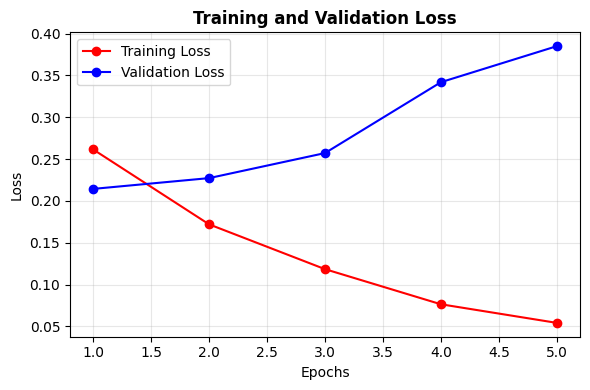

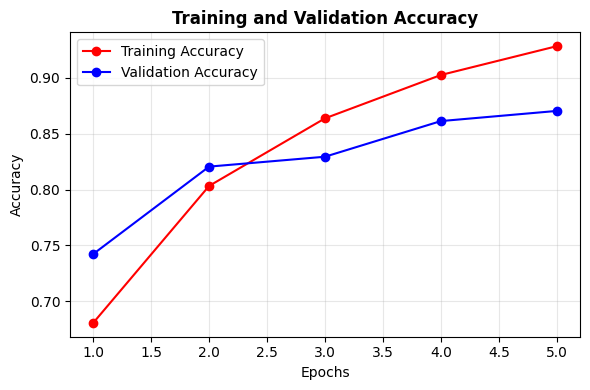

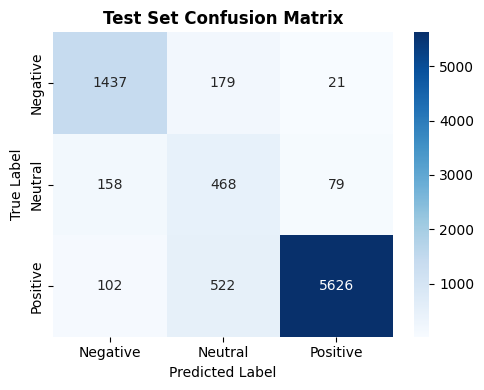

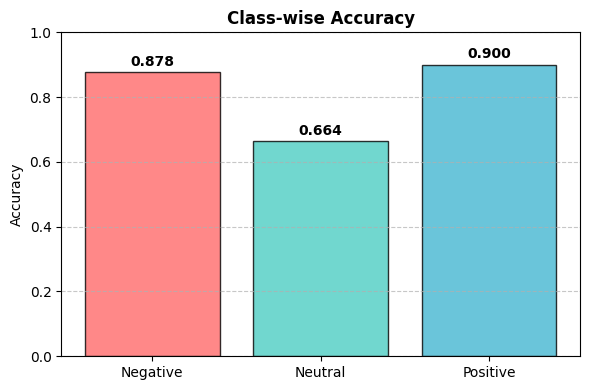

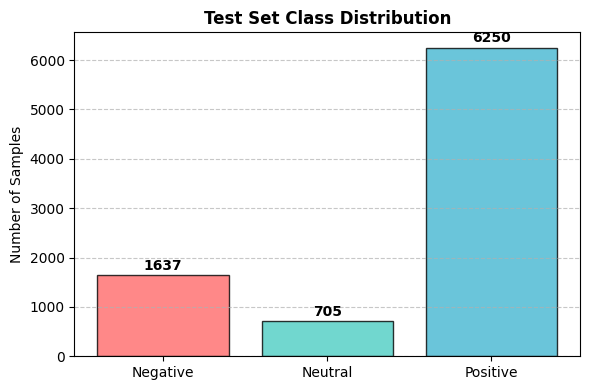

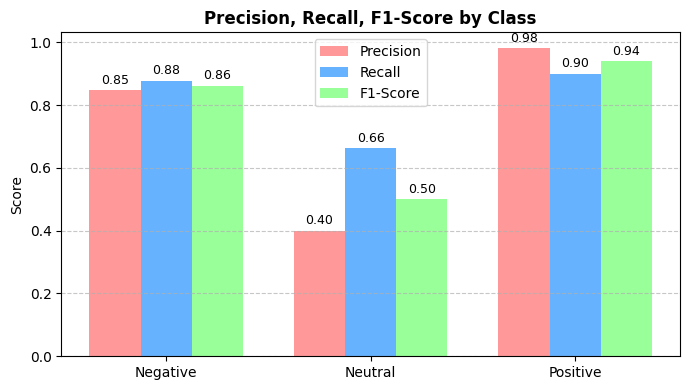

In [27]:
# Generate all graphs separately, in order:
plot_loss_curves(trainer)
plot_accuracy_curves(trainer)
plot_confusion_matrix(y_true_test, y_pred_test)
plot_class_accuracy(class_accuracies)
plot_class_distribution(y_true_test)
plot_prf_by_class(y_true_test, y_pred_test)

# 9. Final test evaluation and classification report

In [24]:
# Enhanced Classification Reports
print("="*80)
print("COMPREHENSIVE CLASSIFICATION ANALYSIS")
print("="*80)

# Validation Set Classification Report
print("\nVALIDATION SET CLASSIFICATION REPORT:")
print("-" * 50)
val_preds = trainer.predict(val_dataset)
y_pred_val = np.argmax(val_preds.predictions, axis=1)
y_true_val = val_preds.label_ids
val_report = classification_report(y_true_val, y_pred_val, 
                                 target_names=["Negative", "Neutral", "Positive"],
                                 output_dict=True)
print(classification_report(y_true_val, y_pred_val, 
                          target_names=["Negative", "Neutral", "Positive"]))

# Test Set Classification Report  
print("\nTEST SET CLASSIFICATION REPORT:")
print("-" * 50)
test_report = classification_report(y_true_test, y_pred_test, 
                                  target_names=["Negative", "Neutral", "Positive"],
                                  output_dict=True)
print(classification_report(y_true_test, y_pred_test, 
                          target_names=["Negative", "Neutral", "Positive"]))

COMPREHENSIVE CLASSIFICATION ANALYSIS

VALIDATION SET CLASSIFICATION REPORT:
--------------------------------------------------


              precision    recall  f1-score   support

    Negative       0.84      0.84      0.84      1637
     Neutral       0.38      0.66      0.49       704
    Positive       0.98      0.90      0.94      6251

    accuracy                           0.87      8592
   macro avg       0.73      0.80      0.76      8592
weighted avg       0.91      0.87      0.88      8592


TEST SET CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86      1637
     Neutral       0.40      0.66      0.50       705
    Positive       0.98      0.90      0.94      6250

    accuracy                           0.88      8592
   macro avg       0.74      0.81      0.77      8592
weighted avg       0.91      0.88      0.89      8592

